# GARCH Volatility Modelling — Nifty 50
### Full Implementation: Data → Fit → Forecast → VaR
---
**Blocks in order:**
1. Install & Import
2. Download Nifty Data
3. Compute Log Returns
4. Visual Check
5. ARCH-LM Test (justify GARCH)
6. Fit GARCH(1,1) — Normal errors
7. Interpret Parameters
8. Conditional Volatility Series
9. Volatility Forecasting
10. 1-Day VaR
11. Refit with Student-t (better for equities)
12. Diagnostics — Standardized Residuals


## Block 1 — Install & Import

In [2]:
# Run this cell first — installs required libraries
# Uncomment the line below if you haven't installed them yet
# !pip install arch yfinance numpy scipy pandas matplotlib statsmodels

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.stats import norm, t as student_t
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0a0a0f',
    'axes.facecolor':   '#111118',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#9999bb',
    'xtick.color':      '#666688',
    'ytick.color':      '#666688',
    'text.color':       '#e8e8f0',
    'grid.color':       '#1e1e2e',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
})

print("All imports successful.")


All imports successful.


## Block 2 — Download Nifty 50 Data

In [3]:
# Nifty 50 ticker on yfinance is ^NSEI
raw = yf.download('^NSEI', start='2015-01-01', end='2026-12-31', auto_adjust=True, progress=False)

# Use closing price
prices = raw['Close'].dropna()
prices.index = pd.to_datetime(prices.index)

print(f"Total trading days downloaded : {len(prices)}")
print(f"First date                    : {prices.index[0].date()}")
print(f"Last date                     : {prices.index[-1].date()}")
print(f"First price                   : {float(prices.iloc[0]):,.2f}")
print(f"Last price                    : {float(prices.iloc[-1]):,.2f}")
print(f"Total return over period      : {((float(prices.iloc[-1]) / float(prices.iloc[0])) - 1)*100:.1f}%")


Total trading days downloaded : 2766
First date                    : 2015-01-02
Last date                     : 2026-03-27
First price                   : 8,395.45
Last price                    : 22,819.60
Total return over period      : 171.8%


## Block 3 — Compute Log Returns

**Why log returns?**
Log return = ln(Pₜ / Pₜ₋₁). Additive over time, approximately symmetric, well-behaved statistically.

**Why multiply by 100?**
The `arch` library's optimizer works best in % scale. Raw decimal returns (like 0.001) cause
numerical precision issues during MLE. Everything downstream stays in % units.


In [5]:
# Log returns in % scale
returns = 100 * np.log(prices / prices.shift(1)).dropna()

print("=" * 48)
print(f"  Observations          : {len(returns)}")
print(f"  Mean daily return     : {float(returns.mean()):.4f}%")
print(f"  Std daily return      : {float(returns.std()):.4f}%")
print(f"  Annualized vol        : {float(returns.std() * np.sqrt(252)):.2f}%")
print(f"  Skewness              : {float(returns.skew()):.4f}")
print(f"  Kurtosis (excess)     : {float(returns.kurt()):.4f}  ← should be > 0 (fat tails)")
print(f"  Min return (worst day): {float(returns.min()):.2f}%")
print(f"  Max return (best day) : {float(returns.max()):.2f}%")
print("=" * 48)

# Kurtosis > 0 means fatter tails than Normal — justifies Student-t later

  Observations          : 2765
  Mean daily return     : 0.0362%
  Std daily return      : 1.0319%
  Annualized vol        : 16.38%
  Skewness              : -1.3359
  Kurtosis (excess)     : 19.9175  ← should be > 0 (fat tails)
  Min return (worst day): -13.90%
  Max return (best day) : 8.40%


## Block 4 — Visual Check

**What to look for:**
- Top chart: return series — should show **volatility clustering** (calm then turbulent patches)
- Bottom chart: squared returns — clusters should be clearly visible (2020 COVID, etc.)

If clustering is visible → GARCH is justified.


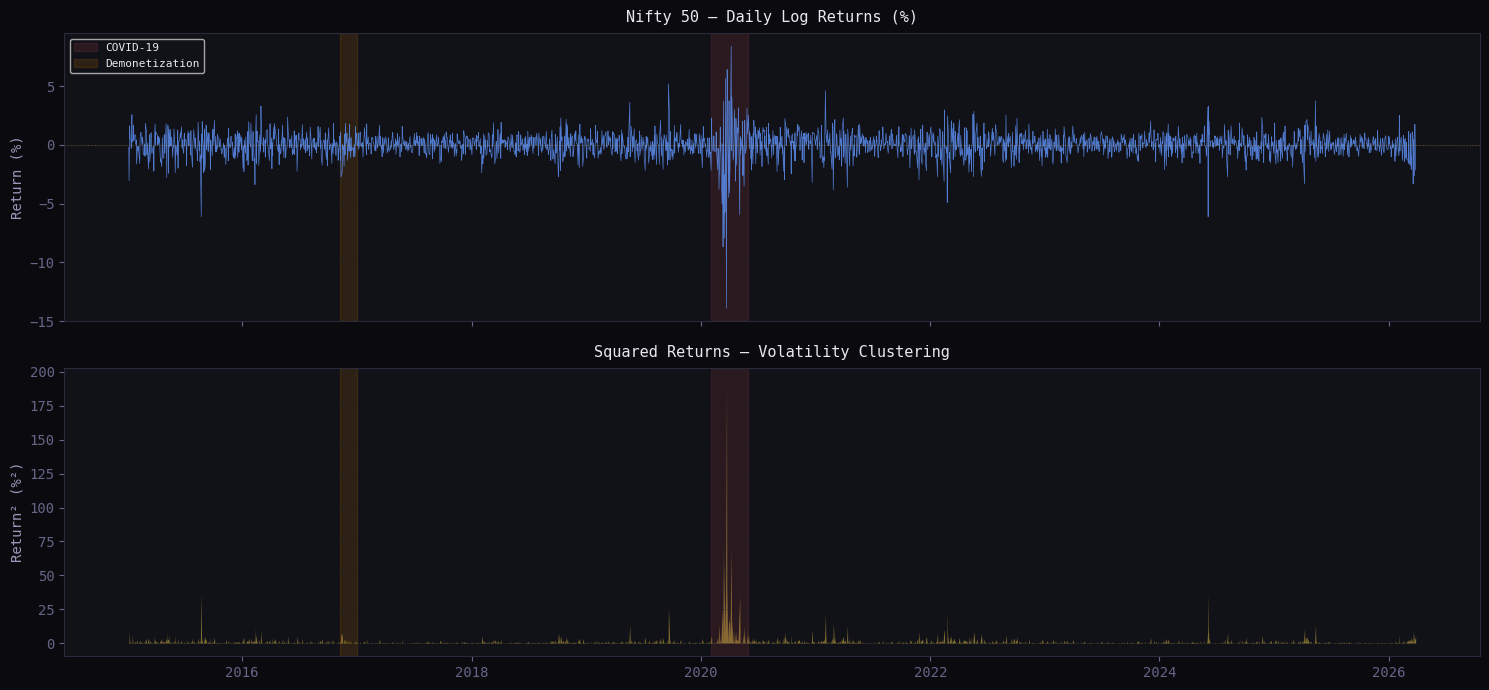

Chart saved as nifty_returns.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

ret_vals = returns.values.flatten()

# Returns
axes[0].plot(returns.index, ret_vals,
             color='#5b8dee', linewidth=0.5, alpha=0.85)
axes[0].axhline(0, color='#e8c547', linewidth=0.4, alpha=0.4, linestyle='--')
axes[0].set_title('Nifty 50 — Daily Log Returns (%)', fontsize=11, pad=8)
axes[0].set_ylabel('Return (%)')
axes[0].grid(True, alpha=0.3)

# Squared returns (proxy for variance)
axes[1].fill_between(returns.index, ret_vals**2,
                     color='#e8c547', alpha=0.5, linewidth=0)
axes[1].set_title('Squared Returns — Volatility Clustering', fontsize=11, pad=8)
axes[1].set_ylabel('Return² (%²)')
axes[1].grid(True, alpha=0.3)

# Annotate key events
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
               alpha=0.12, color='#e05c5c', label='COVID-19')
    ax.axvspan(pd.Timestamp('2016-11-08'), pd.Timestamp('2016-12-31'),
               alpha=0.12, color='#ff9900', label='Demonetization')

axes[0].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('nifty_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as nifty_returns.png")

## Block 5 — ARCH-LM Test

**Before fitting GARCH, confirm ARCH effects actually exist.**

- H₀: No ARCH effects — variance is constant (homoskedastic)
- H₁: ARCH effects present — variance is time-varying

If p-value < 0.05 → reject H₀ → GARCH is justified.


In [11]:
# ARCH-LM test with 10 lags
lm_stat, lm_pval, f_stat, f_pval = het_arch(returns.values.flatten(), nlags=10)

print("=" * 48)
print("  ARCH-LM Test (10 lags)")
print("-" * 48)
print(f"  LM Statistic  : {lm_stat:.4f}")
print(f"  LM p-value    : {lm_pval:.8f}")
print(f"  F  Statistic  : {f_stat:.4f}")
print(f"  F  p-value    : {f_pval:.8f}")
print("-" * 48)
if lm_pval < 0.05:
    print("  VERDICT: p < 0.05 → ARCH effects confirmed ✓")
    print("  GARCH modelling is justified.")
else:
    print("  VERDICT: p > 0.05 → No ARCH effects found")
    print("  GARCH may not be needed.")
print("=" * 48)

  ARCH-LM Test (10 lags)
------------------------------------------------
  LM Statistic  : 713.6071
  LM p-value    : 0.00000000
  F  Statistic  : 95.9217
  F  p-value    : 0.00000000
------------------------------------------------
  VERDICT: p < 0.05 → ARCH effects confirmed ✓
  GARCH modelling is justified.


## Block 6 — Fit GARCH(1,1) with Normal Errors

**Model:**
$$r_t = \mu + \varepsilon_t, \quad \varepsilon_t = \sigma_t z_t, \quad z_t \sim N(0,1)$$
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Estimated by MLE — maximizes the Gaussian log-likelihood over (μ, ω, α, β).


In [12]:
# Specify GARCH(1,1) with constant mean and Normal errors
am_norm = arch_model(
    returns,
    mean='Constant',
    vol='GARCH',
    p=1, q=1,
    dist='normal'
)

# Fit via MLE
res_norm = am_norm.fit(
    disp='off',
    options={'maxiter': 2000}
)

print(res_norm.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^NSEI   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3544.12
Distribution:                  Normal   AIC:                           7096.25
Method:            Maximum Likelihood   BIC:                           7119.95
                                        No. Observations:                 2765
Date:                Sun, Mar 29 2026   Df Residuals:                     2764
Time:                        22:36:01   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0638  1.619e-02      3.943  8.031e-05 [3.

## Block 7 — Extract and Interpret Parameters

Reading the estimated (ω, α, β) and computing derived quantities:
- **Persistence** = α + β
- **Long-run annual vol** = √(ω/(1−α−β) × 252)
- **Half-life** = ln(0.5) / ln(α+β) days


In [13]:
mu    = res_norm.params['mu']
omega = res_norm.params['omega']
alpha = res_norm.params['alpha[1]']
beta  = res_norm.params['beta[1]']

persistence   = alpha + beta
lr_var_daily  = omega / (1 - alpha - beta)   # %² units
lr_vol_annual = np.sqrt(lr_var_daily * 252)  # annualized %
halflife      = np.log(0.5) / np.log(persistence)

print("=" * 52)
print("  GARCH(1,1) — Estimated Parameters")
print("-" * 52)
print(f"  μ  (daily mean return)      : {mu:.5f}%")
print(f"  ω  (base variance)          : {omega:.6f}")
print(f"  α  (shock reactivity)       : {alpha:.5f}")
print(f"  β  (vol persistence)        : {beta:.5f}")
print("-" * 52)
print(f"  Persistence  (α + β)        : {persistence:.5f}")
print(f"  Long-run annual vol         : {lr_vol_annual:.2f}%")
print(f"  Half-life of vol shock      : {halflife:.1f} trading days")
print(f"  Log-Likelihood              : {res_norm.loglikelihood:.2f}")
print(f"  AIC                         : {res_norm.aic:.2f}")
print(f"  BIC                         : {res_norm.bic:.2f}")
print("=" * 52)

# Sanity checks
print()
print("  Constraint checks:")
print(f"  ω > 0         : {omega > 0} ({omega:.6f})")
print(f"  α ≥ 0         : {alpha >= 0} ({alpha:.5f})")
print(f"  β ≥ 0         : {beta >= 0} ({beta:.5f})")
print(f"  α + β < 1     : {persistence < 1} ({persistence:.5f})")


  GARCH(1,1) — Estimated Parameters
----------------------------------------------------
  μ  (daily mean return)      : 0.06383%
  ω  (base variance)          : 0.024010
  α  (shock reactivity)       : 0.10591
  β  (vol persistence)        : 0.87140
----------------------------------------------------
  Persistence  (α + β)        : 0.97731
  Long-run annual vol         : 16.33%
  Half-life of vol shock      : 30.2 trading days
  Log-Likelihood              : -3544.12
  AIC                         : 7096.25
  BIC                         : 7119.95

  Constraint checks:
  ω > 0         : True (0.024010)
  α ≥ 0         : True (0.10591)
  β ≥ 0         : True (0.87140)
  α + β < 1     : True (0.97731)


## Block 8 — Conditional Volatility Series

The fitted σₜ for each day — this is what GARCH actually produces.
Compare it against realized volatility (rolling 21-day std) as a sanity check.


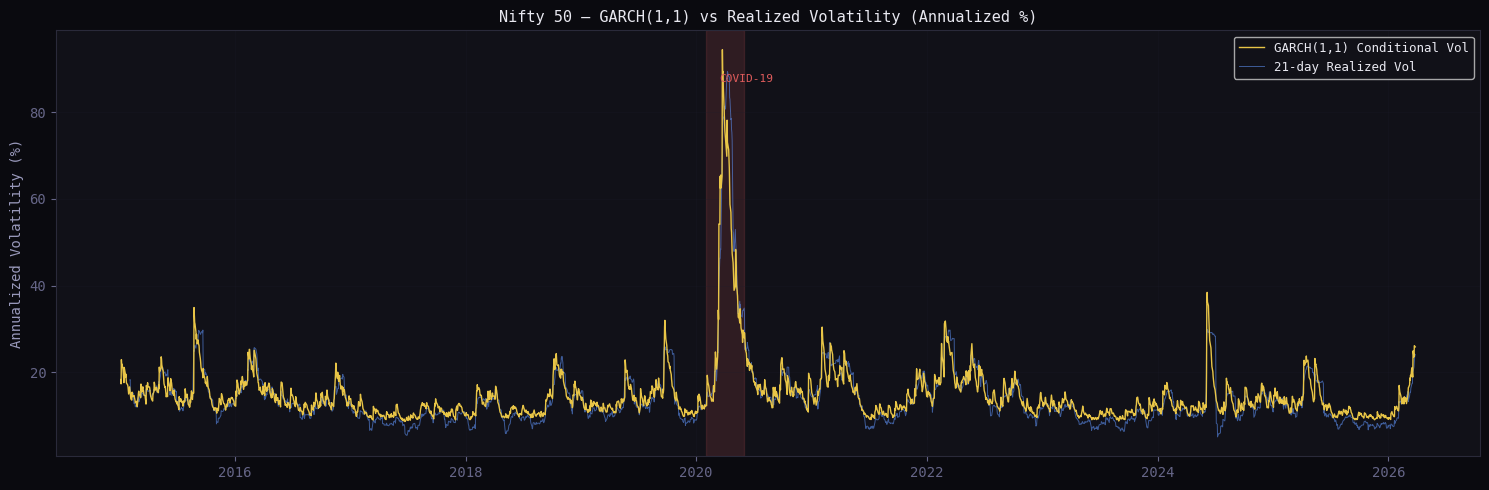

Chart saved as nifty_garch_vol.png

Today's conditional vol  : 1.6283% (daily)
Today's conditional vol  : 25.85% (annualized)


In [14]:
# GARCH conditional vol — daily in %, annualize it
cond_vol_daily  = res_norm.conditional_volatility
cond_vol_annual = cond_vol_daily * np.sqrt(252)

# Realized vol for comparison — rolling 21-day std annualized
realized_vol = returns.rolling(21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(cond_vol_annual.index, cond_vol_annual.values,
        color='#e8c547', linewidth=1.0, label='GARCH(1,1) Conditional Vol', zorder=3)
ax.plot(realized_vol.index, realized_vol.values,
        color='#5b8dee', linewidth=0.7, alpha=0.6, label='21-day Realized Vol', zorder=2)

# Shade COVID spike
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.15, color='#e05c5c')
ax.text(pd.Timestamp('2020-03-15'), cond_vol_annual.max()*0.92,
        'COVID-19', color='#e05c5c', fontsize=8)

ax.set_title('Nifty 50 — GARCH(1,1) vs Realized Volatility (Annualized %)', fontsize=11)
ax.set_ylabel('Annualized Volatility (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nifty_garch_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as nifty_garch_vol.png")
print(f"\nToday's conditional vol  : {float(cond_vol_daily.iloc[-1]):.4f}% (daily)")
print(f"Today's conditional vol  : {float(cond_vol_annual.iloc[-1]):.2f}% (annualized)")


## Block 9 — Volatility Forecasting

GARCH gives you analytical multi-step ahead variance forecasts:
$$\mathbb{E}_t[\sigma_{t+h}^2] = \bar{\sigma}^2 + (\alpha+\beta)^{h-1}(\sigma_{t+1}^2 - \bar{\sigma}^2)$$

Forecast decays from today's level back toward long-run mean — **mean reversion in action**.


Day      Forecast Var (%²)      Forecast Vol (Ann %)  
----------------------------------------------------
  1      2.83540                26.73                 
  2      2.79508                26.54                 
  3      2.75567                26.35                 
  5      2.67952                25.99                 
  10     2.50376                25.12                 
  15     2.34705                24.32                 
  22     2.15578                23.31                 

  Long-run vol target : 16.33%
  (forecast converges toward this level)


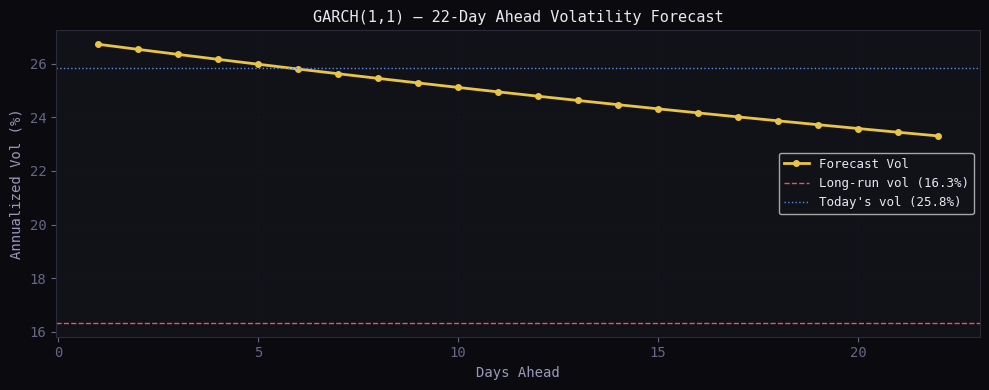

In [15]:
# 22-day ahead forecast (1 trading month)
horizon = 22
forecasts = res_norm.forecast(horizon=horizon, reindex=False)

# Daily variance forecasts in %²
fcast_var = forecasts.variance.iloc[-1]

# Annualized vol forecasts
fcast_vol = np.sqrt(fcast_var * 252)

# Print table
print(f"{'Day':<8} {'Forecast Var (%²)':<22} {'Forecast Vol (Ann %)':<22}")
print("-" * 52)
for h in [1, 2, 3, 5, 10, 15, 22]:
    print(f"  {h:<6} {float(fcast_var.iloc[h-1]):<22.5f} {float(fcast_vol.iloc[h-1]):<22.2f}")

print(f"\n  Long-run vol target : {lr_vol_annual:.2f}%")
print(f"  (forecast converges toward this level)")

# Plot the forecast term structure
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, horizon+1), fcast_vol.values,
        color='#e8c547', linewidth=2, marker='o', markersize=4, label='Forecast Vol')
ax.axhline(lr_vol_annual, color='#e05c5c', linewidth=1,
           linestyle='--', label=f'Long-run vol ({lr_vol_annual:.1f}%)')
ax.axhline(float(cond_vol_annual.iloc[-1]), color='#5b8dee', linewidth=1,
           linestyle=':', label=f"Today's vol ({float(cond_vol_annual.iloc[-1]):.1f}%)")
ax.set_xlabel('Days Ahead')
ax.set_ylabel('Annualized Vol (%)')
ax.set_title('GARCH(1,1) — 22-Day Ahead Volatility Forecast', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nifty_garch_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## Block 10 — 1-Day VaR from GARCH

**Using today's conditional volatility σₜ to compute VaR:**

$$\text{VaR}_{1d,\alpha} = -(\mu + z_\alpha \cdot \sigma_t)$$

where $z_\alpha$ is the quantile of the assumed return distribution.


In [16]:
today_vol_daily = float(cond_vol_daily.iloc[-1])   # in %
today_mu        = mu                                # daily mean in %

# Portfolio size
portfolio_inr = 1_00_00_000   # ₹1 crore

print("=" * 55)
print("  1-Day VaR — GARCH(1,1) with Normal Errors")
print(f"  Today's σₜ = {today_vol_daily:.4f}% (daily)")
print("-" * 55)
print(f"  {'Confidence':<14} {'VaR (%)':<14} {'VaR (₹1Cr portfolio)'}")
print("-" * 55)

for cl in [0.90, 0.95, 0.99, 0.999]:
    q      = norm.ppf(1 - cl)
    var_pct = -(today_mu + q * today_vol_daily)
    var_inr = portfolio_inr * var_pct / 100
    print(f"  {cl*100:.1f}%          {var_pct:<14.3f} ₹{var_inr:>12,.0f}")

print("=" * 55)
print()
print("  Interpretation: 99% VaR means on 99 out of 100 days,")
print("  the loss will NOT exceed the VaR figure.")
print("  On 1 out of 100 days, it will (that's an exceedance).")


  1-Day VaR — GARCH(1,1) with Normal Errors
  Today's σₜ = 1.6283% (daily)
-------------------------------------------------------
  Confidence     VaR (%)        VaR (₹1Cr portfolio)
-------------------------------------------------------
  90.0%          2.023          ₹     202,293
  95.0%          2.615          ₹     261,450
  99.0%          3.724          ₹     372,419
  99.9%          4.968          ₹     496,803

  Interpretation: 99% VaR means on 99 out of 100 days,
  the loss will NOT exceed the VaR figure.
  On 1 out of 100 days, it will (that's an exceedance).


## Block 11 — Refit with Student-t Errors

Daily equity returns have **fat tails** — kurtosis > 3. The Normal distribution underestimates
tail probabilities, making VaR too optimistic at high confidence levels.

Student-t with ν degrees of freedom has fatter tails. As ν → ∞, it converges to Normal.
Typical equity fit: ν ≈ 5–8.


In [17]:
# GARCH(1,1) with Student-t errors
am_t = arch_model(
    returns,
    mean='Constant',
    vol='GARCH',
    p=1, q=1,
    dist='StudentsT'
)

res_t = am_t.fit(disp='off', options={'maxiter': 2000})
print(res_t.summary())

# Model comparison
print()
print("=" * 45)
print("  Model Comparison (lower AIC/BIC = better)")
print("-" * 45)
print(f"  Normal   AIC: {res_norm.aic:>10.2f}  BIC: {res_norm.bic:>10.2f}")
print(f"  Student-t AIC: {res_t.aic:>10.2f}  BIC: {res_t.bic:>10.2f}")
print("-" * 45)
delta_aic = res_norm.aic - res_t.aic
print(f"  ΔAIC (Normal - Student-t): {delta_aic:.2f}")
if delta_aic > 0:
    print("  Student-t wins — use this for VaR.")
else:
    print("  Normal wins — use that for VaR.")
print("=" * 45)


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        ^NSEI   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3476.18
Distribution:      Standardized Student's t   AIC:                           6962.36
Method:                  Maximum Likelihood   BIC:                           6991.98
                                              No. Observations:                 2765
Date:                      Sun, Mar 29 2026   Df Residuals:                     2764
Time:                              22:41:07   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [18]:
# VaR comparison: Normal vs Student-t
nu = res_t.params['nu']   # estimated degrees of freedom
today_vol_t = float(res_t.conditional_volatility.iloc[-1])
today_mu_t  = res_t.params['mu']

print(f"  Student-t degrees of freedom (ν) = {nu:.2f}")
print(f"  (lower ν = fatter tails; Normal is ν → ∞)")
print()
print("=" * 60)
print("  1-Day 99% VaR Comparison")
print("-" * 60)

# Normal VaR
q_norm = norm.ppf(0.01)
var_norm = -(today_mu + q_norm * today_vol_daily)

# Student-t VaR (scale by sqrt((nu-2)/nu) to normalize)
q_t  = student_t.ppf(0.01, df=nu)
var_t = -(today_mu_t + q_t * today_vol_t)

print(f"  Normal   99% VaR : {var_norm:.3f}%")
print(f"  Student-t 99% VaR: {var_t:.3f}%")
print(f"  Difference        : {var_t - var_norm:.3f}%")
print()
print("  Student-t VaR is larger — it correctly accounts")
print("  for the higher probability of extreme moves.")
print("=" * 60)


  Student-t degrees of freedom (ν) = 6.64
  (lower ν = fatter tails; Normal is ν → ∞)

  1-Day 99% VaR Comparison
------------------------------------------------------------
  Normal   99% VaR : 3.724%
  Student-t 99% VaR: 4.583%
  Difference        : 0.859%

  Student-t VaR is larger — it correctly accounts
  for the higher probability of extreme moves.


## Block 12 — Diagnostics

**The key question:** Did GARCH capture all the variance dynamics?

If yes → standardized residuals $\hat{z}_t = \varepsilon_t / \sigma_t$ should look like i.i.d. N(0,1) (or Student-t).

**Tests:**
1. Ljung-Box on $\hat{z}_t^2$ — no remaining autocorrelation in variance
2. ARCH-LM on $\hat{z}_t$ — no remaining ARCH effects
3. Histogram of $\hat{z}_t$ vs assumed distribution


In [19]:
# Use Student-t model results for diagnostics
std_resid = res_t.std_resid   # standardized residuals ẑₜ = εₜ/σₜ

print("Standardized Residuals Summary:")
print(f"  Mean     : {std_resid.mean():.4f}  (should be ≈ 0)")
print(f"  Std      : {std_resid.std():.4f}  (should be ≈ 1)")
print(f"  Skewness : {std_resid.skew():.4f}")
print(f"  Kurtosis : {std_resid.kurt():.4f}  (should be ≈ 0 if t-dist fit is good)")
print()

# Ljung-Box on ẑₜ² — test for remaining ARCH effects
lb_result = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)
print("Ljung-Box Test on ẑₜ² (H₀: no autocorrelation in squared residuals):")
print(f"  {'Lag':<8} {'LB Stat':<14} {'p-value':<14} {'Verdict'}")
print("-" * 55)
for lag, row in lb_result.iterrows():
    verdict = "✓ Pass" if row['lb_pvalue'] > 0.05 else "✗ Fail — ARCH effects remain"
    print(f"  {lag:<8} {row['lb_stat']:<14.4f} {row['lb_pvalue']:<14.4f} {verdict}")

print()

# ARCH-LM on standardized residuals
lm_s, lm_p, _, _ = het_arch(std_resid.values.flatten(), nlags=10)
print(f"ARCH-LM on ẑₜ (10 lags):")
print(f"  LM stat  : {lm_s:.4f}")
print(f"  p-value  : {lm_p:.6f}")
verdict = "✓ No remaining ARCH effects — model adequate" if lm_p > 0.05 else "✗ Remaining ARCH effects — consider EGARCH/GJR"
print(f"  Verdict  : {verdict}")

Standardized Residuals Summary:
  Mean     : -0.0501  (should be ≈ 0)
  Std      : 1.0016  (should be ≈ 1)
  Skewness : -0.4211
  Kurtosis : 2.2009  (should be ≈ 0 if t-dist fit is good)

Ljung-Box Test on ẑₜ² (H₀: no autocorrelation in squared residuals):
  Lag      LB Stat        p-value        Verdict
-------------------------------------------------------
  5        8.2109         0.1450         ✓ Pass
  10       15.3707        0.1191         ✓ Pass
  20       21.1977        0.3856         ✓ Pass

ARCH-LM on ẑₜ (10 lags):
  LM stat  : 16.3293
  p-value  : 0.090585
  Verdict  : ✓ No remaining ARCH effects — model adequate


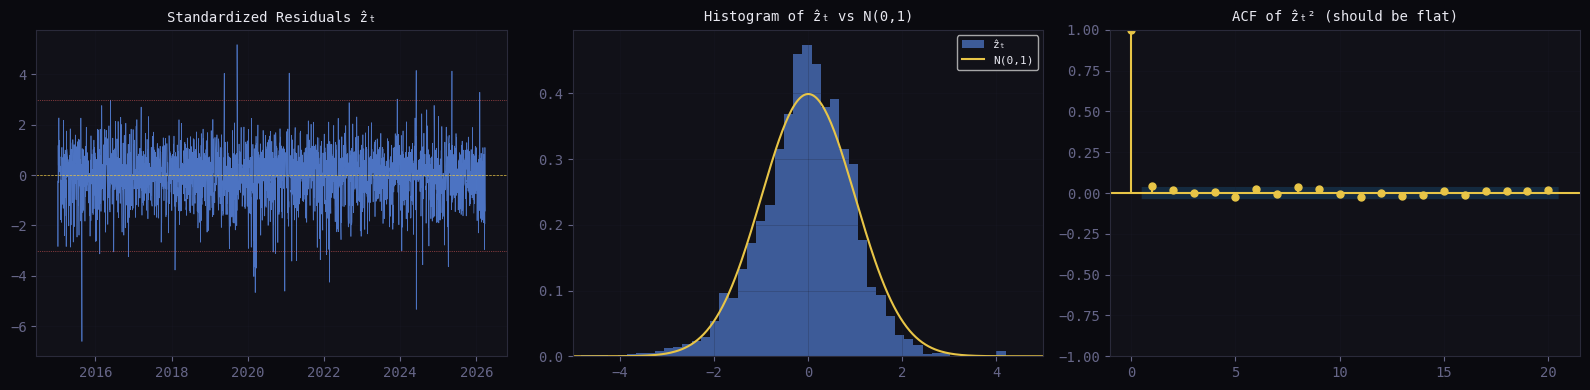

Diagnostics chart saved as nifty_diagnostics.png


In [20]:
# Visual diagnostics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Standardized residuals over time
axes[0].plot(std_resid.index, std_resid.values,
             color='#5b8dee', linewidth=0.5, alpha=0.8)
axes[0].axhline(0,  color='#e8c547', linewidth=0.5, linestyle='--')
axes[0].axhline(3,  color='#e05c5c', linewidth=0.5, linestyle=':')
axes[0].axhline(-3, color='#e05c5c', linewidth=0.5, linestyle=':')
axes[0].set_title('Standardized Residuals ẑₜ', fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Histogram vs Normal
x = np.linspace(-5, 5, 300)
axes[1].hist(std_resid.values, bins=60, density=True,
             color='#5b8dee', alpha=0.6, label='ẑₜ')
axes[1].plot(x, norm.pdf(x), color='#e8c547',
             linewidth=1.5, label='N(0,1)')
axes[1].set_title('Histogram of ẑₜ vs N(0,1)', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_xlim(-5, 5)
axes[1].grid(True, alpha=0.3)

# 3. ACF of ẑₜ²
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=20, ax=axes[2],
         color='#e8c547', vlines_kwargs={'color':'#e8c547'})
axes[2].set_title('ACF of ẑₜ² (should be flat)', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nifty_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagnostics chart saved as nifty_diagnostics.png")


---
## Summary

| Step | What we did |
|---|---|
| Block 2–3 | Downloaded Nifty 50 prices, computed log returns in % |
| Block 4 | Visualized clustering — justified GARCH visually |
| Block 5 | ARCH-LM test — confirmed ARCH effects statistically |
| Block 6–7 | Fitted GARCH(1,1), extracted ω, α, β, persistence, half-life |
| Block 8 | Plotted conditional volatility σₜ vs realized vol |
| Block 9 | Forecasted σₜ₊ₕ — saw mean reversion toward long-run vol |
| Block 10 | Computed 1-day VaR at 90%, 95%, 99%, 99.9% |
| Block 11 | Refitted with Student-t — compared AIC/BIC, recomputed VaR |
| Block 12 | Diagnostics — Ljung-Box, ARCH-LM, histogram of ẑₜ |

**Next steps:** Try EGARCH or GJR-GARCH to capture the leverage effect (negative returns spike vol more than positive).
